In [1]:
import numpy as np
import pandas as pd
import glob
from helper import get_data_splits, id_key, get_model
from define_model import create_MultiTaskTouchPoseNet
from my_helpers import *
from itertools import zip_longest
import pprint as p

2023-07-17 09:52:33.644159: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-17 09:52:34.516621: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Below identifiers correspond to evaluation protocol 1, 2 and 3 respectively
# identifiers - "TouchPose_crossSession", "TouchPose_crossSubjects", "TouchPose_crossGestures"
identifier = "TouchPose_crossGestures"
data_path = "../data/eth_data/"
model_path = "../models/"
new_data = "../data/27Arish"

In [4]:
files = glob.glob(data_path+'*.pkl')
df = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)

In [5]:
control = id_key[identifier]
df_group = df.groupby([control])[["cap_img","depth_img"]]
g_id = list(df_group.groups.keys())

In [6]:
depth_err = []
for i in range(len(g_id)):
    test_set = [g_id[i]]
    X_test_cap, Y_test_depth= get_data_splits(df_group,test_set)
    model = get_model(identifier, model_path, test_set)
    Y_out_depth = model.predict(X_test_cap, batch_size=128)
    depth_error = np.mean(abs(Y_test_depth - Y_out_depth[:,:,:,0])) * 255
    depth_err.append(depth_error)
    print("Accuracy", g_id[i],depth_error)
    break


2023-07-17 09:52:38.506224: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-07-17 09:52:38.535788: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-07-17 09:52:38.536742: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

2023-07-17 09:52:40.601086: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2023-07-17 09:52:41.159531: E tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:114] *** WARNING *** You are using ptxas 9.1.108, which is older than 11.1. ptxas before 11.1 is known to miscompile XLA code, leading to incorrect results or invalid-address errors.



42/42 [==============================] - 10s 160ms/step
Accuracy 65.0 30.418464459312894


In [7]:
model.layers

In [8]:
multi_task_model = create_MultiTaskTouchPoseNet(41, 72, 1)

## Now we will assign weights to multi task model from depth model

In [9]:
match = []
for depth_layer, multi_layer, matching in zip_longest(model.layers,multi_task_model.layers,range(len(multi_task_model.layers)),fillvalue='0'):
        if(depth_layer!='0'):
            match.append((depth_layer.name, multi_layer.name, (matching,matching)))
        else : 
            match.append((depth_layer, multi_layer.name,(matching,matching)))
match

[('input_25', 'input_1', (0, 0)),
 ('conv2d_336', 'conv2d', (1, 1)),
 ('conv2d_337', 'conv2d_1', (2, 2)),
 ('max_pooling2d_72', 'max_pooling2d', (3, 3)),
 ('conv2d_338', 'conv2d_2', (4, 4)),
 ('conv2d_339', 'conv2d_3', (5, 5)),
 ('max_pooling2d_73', 'max_pooling2d_1', (6, 6)),
 ('conv2d_340', 'conv2d_4', (7, 7)),
 ('conv2d_341', 'conv2d_5', (8, 8)),
 ('max_pooling2d_74', 'max_pooling2d_2', (9, 9)),
 ('conv2d_342', 'conv2d_6', (10, 10)),
 ('conv2d_343', 'conv2d_7', (11, 11)),
 ('up_sampling2d_72', 'up_sampling2d', (12, 12)),
 ('concatenate_72', 'concatenate', (13, 13)),
 ('conv2d_344', 'conv2d_8', (14, 14)),
 ('conv2d_345', 'conv2d_9', (15, 15)),
 ('up_sampling2d_73', 'up_sampling2d_1', (16, 16)),
 ('concatenate_73', 'concatenate_1', (17, 17)),
 ('conv2d_346', 'conv2d_10', (18, 18)),
 ('conv2d_347', 'flatten', (19, 19)),
 ('up_sampling2d_74', 'conv2d_11', (20, 20)),
 ('tf.compat.v1.pad_24', 'dense', (21, 21)),
 ('concatenate_74', 'up_sampling2d_2', (22, 22)),
 ('conv2d_348', 'activation

In [10]:
match = [ (''.join([ xi for xi in x[0] if not (xi.isdigit() or xi== '_')]),''.join([ xi for xi in x[1] if not (xi.isdigit() or xi== '_')]), x[2]) for x in match]
bad_match = [x for x in match if x[0]!=x[1]]
bad_match

[('convd', 'flatten', (19, 19)),
 ('upsamplingd', 'convd', (20, 20)),
 ('tf.compat.v.pad', 'dense', (21, 21)),
 ('concatenate', 'upsamplingd', (22, 22)),
 ('convd', 'activation', (23, 23)),
 ('convd', 'tf.compat.v.pad', (24, 24)),
 ('regressiondepth', 'batchnormalization', (25, 25)),
 ('', 'concatenate', (26, 26)),
 ('', 'dropout', (27, 27)),
 ('', 'convd', (28, 28)),
 ('', 'dense', (29, 29)),
 ('', 'convd', (30, 30)),
 ('', 'regression', (31, 31)),
 ('', 'visibility', (32, 32)),
 ('', 'regressiondepth', (33, 33))]

In [11]:
bad_match_sec = bad_match.copy()

for i in range(len(bad_match)):
    for j in range(len(bad_match_sec)):
        if bad_match[i][0]==bad_match_sec[j][1]:
            new_match = list(bad_match[i])
            new_match[1] = bad_match_sec[j][1]
            new_match[2] = (bad_match[i][2][0],bad_match_sec[j][2][1])
            bad_match[i] = tuple(new_match)
            bad_match_sec.remove(bad_match_sec[j])
            break

bad_match

[('convd', 'convd', (19, 20)),
 ('upsamplingd', 'upsamplingd', (20, 22)),
 ('tf.compat.v.pad', 'tf.compat.v.pad', (21, 24)),
 ('concatenate', 'concatenate', (22, 26)),
 ('convd', 'convd', (23, 28)),
 ('convd', 'convd', (24, 30)),
 ('regressiondepth', 'regressiondepth', (25, 33)),
 ('', 'concatenate', (26, 26)),
 ('', 'dropout', (27, 27)),
 ('', 'convd', (28, 28)),
 ('', 'dense', (29, 29)),
 ('', 'convd', (30, 30)),
 ('', 'regression', (31, 31)),
 ('', 'visibility', (32, 32)),
 ('', 'regressiondepth', (33, 33))]

In [12]:
good_match = [x for x in match if x[0]==x[1]]
match = [x for x in good_match + bad_match if x[0]==x[1]]
match

[('input', 'input', (0, 0)),
 ('convd', 'convd', (1, 1)),
 ('convd', 'convd', (2, 2)),
 ('maxpoolingd', 'maxpoolingd', (3, 3)),
 ('convd', 'convd', (4, 4)),
 ('convd', 'convd', (5, 5)),
 ('maxpoolingd', 'maxpoolingd', (6, 6)),
 ('convd', 'convd', (7, 7)),
 ('convd', 'convd', (8, 8)),
 ('maxpoolingd', 'maxpoolingd', (9, 9)),
 ('convd', 'convd', (10, 10)),
 ('convd', 'convd', (11, 11)),
 ('upsamplingd', 'upsamplingd', (12, 12)),
 ('concatenate', 'concatenate', (13, 13)),
 ('convd', 'convd', (14, 14)),
 ('convd', 'convd', (15, 15)),
 ('upsamplingd', 'upsamplingd', (16, 16)),
 ('concatenate', 'concatenate', (17, 17)),
 ('convd', 'convd', (18, 18)),
 ('convd', 'convd', (19, 20)),
 ('upsamplingd', 'upsamplingd', (20, 22)),
 ('tf.compat.v.pad', 'tf.compat.v.pad', (21, 24)),
 ('concatenate', 'concatenate', (22, 26)),
 ('convd', 'convd', (23, 28)),
 ('convd', 'convd', (24, 30)),
 ('regressiondepth', 'regressiondepth', (25, 33))]

In [13]:
for i in range(len(model.layers)):
    d = match[i][2][0]
    m = match[i][2][1]
    multi_task_model.layers[m].set_weights(model.layers[d].get_weights())

## Model is partially loaded

In [14]:
p.pprint(model.input)
print('multi model')
p.pprint(multi_task_model.input)

<KerasTensor: shape=(None, 41, 72, 1) dtype=float32 (created by layer 'input_25')>
multi model
<KerasTensor: shape=(None, 41, 72, 1) dtype=float32 (created by layer 'input_1')>


In [15]:
p.pprint(model.output)
print('multi model')
p.pprint(multi_task_model.output)


<KerasTensor: shape=(None, 41, 72, 1) dtype=float32 (created by layer 'regression_depth')>
multi model
[<KerasTensor: shape=(None, 63) dtype=float32 (created by layer 'regression')>,
 <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'visibility')>,
 <KerasTensor: shape=(None, 41, 72, 1) dtype=float32 (created by layer 'regression_depth')>]


In [16]:
cap_img = read_cap_img(new_data+"/Arish_1_UP_100_rawdata.csv")
skeleton = read_skeleton(new_data+"/userarish_2023-04-03_10-10-07_11956_handleap.csv")

In [17]:
skeleton.Timestamp = skeleton.Timestamp.astype('int64')*1000
cap_img = cap_img.rename(columns={'TimeStamps': 'Timestamp'})
cap_img.head()

,Timestamp,MergeTimeStamps,ScanSizeX,ScanSizeY,img
0,1680508053473,1680508053470,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1680508053489,1680508053485,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,1680508053506,1680508053505,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,1680508053519,1680508053515,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,1680508053532,1680508053530,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [18]:
both=pd.merge(skeleton, cap_img[['img','Timestamp']], on='Timestamp', how='inner') 
print(len(both))
both.columns

347


Index(['Timestamp', 'wrist_x', 'wrist_y', 'wrist_z', 'Thumb_0_x', 'Thumb_0_y',
       'Thumb_0_z', 'Thumb_1_x', 'Thumb_1_y', 'Thumb_1_z', 'Thumb_2_x',
       'Thumb_2_y', 'Thumb_2_z', 'Thumb_3_x', 'Thumb_3_y', 'Thumb_3_z',
       'Index_0_x', 'Index_0_y', 'Index_0_z', 'Index_1_x', 'Index_1_y',
       'Index_1_z', 'Index_2_x', 'Index_2_y', 'Index_2_z', 'Index_3_x',
       'Index_3_y', 'Index_3_z', 'Middle_0_x', 'Middle_0_y', 'Middle_0_z',
       'Middle_1_x', 'Middle_1_y', 'Middle_1_z', 'Middle_2_x', 'Middle_2_y',
       'Middle_2_z', 'Middle_3_x', 'Middle_3_y', 'Middle_3_z', 'Ring_0_x',
       'Ring_0_y', 'Ring_0_z', 'Ring_1_x', 'Ring_1_y', 'Ring_1_z', 'Ring_2_x',
       'Ring_2_y', 'Ring_2_z', 'Ring_3_x', 'Ring_3_y', 'Ring_3_z', 'Pinky_0_x',
       'Pinky_0_y', 'Pinky_0_z', 'Pinky_1_x', 'Pinky_1_y', 'Pinky_1_z',
       'Pinky_2_x', 'Pinky_2_y', 'Pinky_2_z', 'Pinky_3_x', 'Pinky_3_y',
       'Pinky_3_z', 'img'],
      dtype='object')

In [19]:
input = prepare_input(both)
input.shape

(347, 41, 72)

In [20]:
ys=multi_task_model.predict(input, batch_size=128)

3/3 [==============================] - 2s 732ms/step


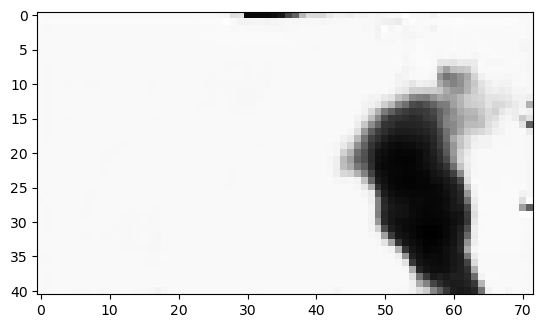

In [21]:
plt.imshow(ys[2][0], cmap='gray')

Same result as before for depth, now prepare skeleton data

In [22]:
both.columns

Index(['Timestamp', 'wrist_x', 'wrist_y', 'wrist_z', 'Thumb_0_x', 'Thumb_0_y',
       'Thumb_0_z', 'Thumb_1_x', 'Thumb_1_y', 'Thumb_1_z', 'Thumb_2_x',
       'Thumb_2_y', 'Thumb_2_z', 'Thumb_3_x', 'Thumb_3_y', 'Thumb_3_z',
       'Index_0_x', 'Index_0_y', 'Index_0_z', 'Index_1_x', 'Index_1_y',
       'Index_1_z', 'Index_2_x', 'Index_2_y', 'Index_2_z', 'Index_3_x',
       'Index_3_y', 'Index_3_z', 'Middle_0_x', 'Middle_0_y', 'Middle_0_z',
       'Middle_1_x', 'Middle_1_y', 'Middle_1_z', 'Middle_2_x', 'Middle_2_y',
       'Middle_2_z', 'Middle_3_x', 'Middle_3_y', 'Middle_3_z', 'Ring_0_x',
       'Ring_0_y', 'Ring_0_z', 'Ring_1_x', 'Ring_1_y', 'Ring_1_z', 'Ring_2_x',
       'Ring_2_y', 'Ring_2_z', 'Ring_3_x', 'Ring_3_y', 'Ring_3_z', 'Pinky_0_x',
       'Pinky_0_y', 'Pinky_0_z', 'Pinky_1_x', 'Pinky_1_y', 'Pinky_1_z',
       'Pinky_2_x', 'Pinky_2_y', 'Pinky_2_z', 'Pinky_3_x', 'Pinky_3_y',
       'Pinky_3_z', 'img'],
      dtype='object')

In [24]:
data = both.copy()
hand_cords = data.drop(["img","Timestamp"],axis=1)
data['skeleton'] = hand_cords.values.tolist()
data = data.drop(hand_cords.columns, axis=1)
data.skeleton = data.skeleton.map(lambda x: np.array(x).reshape(21,3))
#data.img = data.img.map(lambda x: )
data

,Timestamp,img,skeleton
0,1680508085000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[-317.40142822265625, 287.15411376953125, 155..."
1,1680508085000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[-317.280029296875, 287.58367919921875, 154.6..."
2,1680508085000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[-318.2112731933594, 287.7126159667969, 153.6..."
3,1680508085000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[-318.85662841796875, 287.4725036621094, 153...."
4,1680508085000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[-318.9750366210937, 286.9253845214844, 152.5..."
...,...,...,...
342,1680508122000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[-301.4096984863281, 300.8387756347656, 170.4..."
343,1680508122000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[-301.7422790527344, 300.93621826171875, 170...."
344,1680508122000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[-302.0606994628906, 301.0434875488281, 170.1..."
345,1680508122000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[-302.03582763671875, 301.0878295898437, 169...."


In [27]:
input = prepare_input(data)
input.shape

(347, 41, 72)

In [28]:
ys = multi_task_model.predict(input, batch_size=128)

3/3 [==============================] - 0s 56ms/step


In [32]:
real_hand=data.skeleton.iloc[0]
real_hand

array([[-317.40142822,  287.15411377,  155.69587708],
       [-284.64935303,  299.30432129,  135.39683533],
       [-284.64935303,  299.30432129,  135.39683533],
       [-272.82525635,  305.92462158,  101.83241272],
       [-265.43875122,  312.92047119,   72.33328247],
       [-296.08694458,  280.14666748,  144.13217163],
       [-266.91067505,  277.76437378,   86.59494019],
       [-256.52249146,  299.52166748,   65.37322998],
       [-261.90896606,  316.22753906,   69.67178345],
       [-306.18722534,  277.24981689,  136.06147766],
       [-286.23773193,  274.30477905,   78.25802612],
       [-270.75524902,  291.85348511,   45.96550751],
       [-268.28152466,  309.53347778,   44.11845016],
       [-311.59783936,  278.54135132,  127.35361481],
       [-301.70880127,  275.45605469,   73.37324524],
       [-290.77227783,  269.14672852,   33.47851944],
       [-287.0748291 ,  276.06048584,   15.97420883],
       [-319.54052734,  283.88833618,  124.46710205],
       [-317.41165161,  278.

In [30]:
pred_hand=ys[0][0].reshape(21,3)
pred_hand

array([[ 14.370699  , -50.300793  ,  -3.9130745 ],
       [  1.6645994 ,  -5.224186  ,  53.132915  ],
       [ 15.383583  , -25.664858  ,  -5.758337  ],
       [ 18.691267  ,  26.352554  ,  23.364504  ],
       [-17.719988  , -13.5736065 , -31.59568   ],
       [ 38.78091   ,  13.219433  , -33.6529    ],
       [ -2.5449204 , -11.156719  ,  -2.967472  ],
       [-26.682621  ,   8.117552  , -46.635742  ],
       [ 44.18092   ,  25.5797    ,  15.166201  ],
       [ 23.979479  , -11.164864  ,  54.242115  ],
       [  1.2549763 ,  -9.323013  ,  -9.764721  ],
       [-35.94515   ,  66.264     ,  17.4794    ],
       [ 24.871284  , -65.29455   ,  28.795235  ],
       [-16.600714  ,  10.304603  , -37.340137  ],
       [-19.341488  ,  15.623662  , -38.48475   ],
       [ 20.911837  , -42.2024    ,  17.829395  ],
       [-39.910797  ,  -9.208351  ,  -3.9482517 ],
       [ 33.850304  , -67.52809   , -28.882002  ],
       [ -5.704853  , -21.895329  ,  -2.3314877 ],
       [ 19.71103   , -37.34235

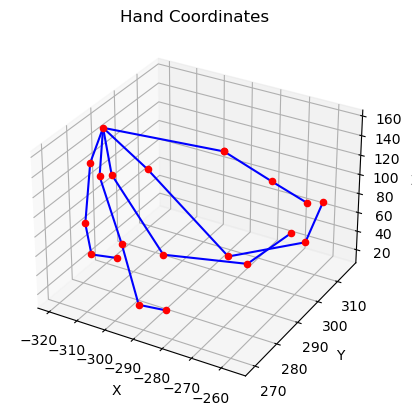

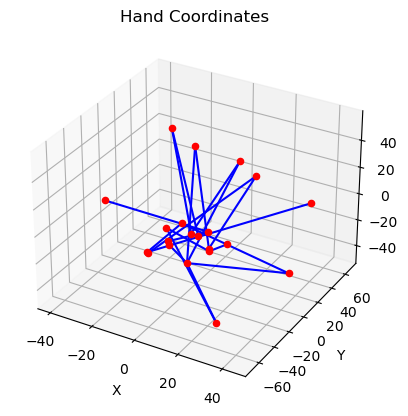

In [33]:
plot_hand(real_hand)
plot_hand(pred_hand)

Train the model

In [ ]:
model = create_MultiTaskTouchPoseNet(41, 72, 1)
model.compile(optimizer='adam', loss={'regression': 'mse', 'visibility': 'binary_crossentropy', 'regression_depth': 'mse'})

In [ ]:
from sklearn.model_selection import train_test_split

# Extract the features and targets from the DataFrame
timestamps = data['Timestamp']
images = data['img']
skeletons = data['skeleton']

# Preprocess the features (images) and reshape them if necessary
x = np.array(images)  # Convert the images column to a NumPy array
x = x.reshape(-1, height, width, depth)  # Reshape the images to match your inputShape

# Preprocess the targets (regression, visibility, and regression_depth)
y_regress = np.array(data['regression'])  # Assuming 'regression' is a column in the DataFrame
y_vis = np.array(data['visibility'])  # Assuming 'visibility' is a column in the DataFrame
y_depth = np.array(data['regression_depth'])  # Assuming 'regression_depth' is a column in the DataFrame

# Split the data into training and validation sets
x_train, x_val, y_regress_train, y_regress_val, y_vis_train, y_vis_val, y_depth_train, y_depth_val = train_test_split(
    x, y_regress, y_vis, y_depth, test_size=0.2, random_state=42)

# Print the shapes of the training and validation sets
print("x_train shape:", x_train.shape)
print("y_regress_train shape:", y_regress_train.shape)
print("y_vis_train shape:", y_vis_train.shape)
print("y_depth_train shape:", y_depth_train.shape)
print("x_val shape:", x_val.shape)
print("y_regress_val shape:", y_regress_val.shape)
print("y_vis_val shape:", y_vis_val.shape)
print("y_depth_val shape:", y_depth_val.shape)

In [ ]:
model.fit(x_train, {'regression': y_regress_train, 'visibility': y_vis_train, 'regression_depth': y_depth_train}, 
          validation_data=(x_val, {'regression': y_regress_val, 'visibility': y_vis_val, 'regression_depth': y_depth_val}), 
          batch_size=32, epochs=10)

In [ ]:
losses = model.evaluate(x_test, {'regression': y_regress_test, 'visibility': y_vis_test, 'regression_depth': y_depth_test})
print('Test Losses:', losses)

In [ ]:
predictions = model.predict(x_new_data)